# League of Legends Diamond Ranked: Previsão de Vitória

Este notebook apresenta um fluxo de classificação em aprendizado de máquina com o objetivo de prever se o time azul vence (`blueWins`) com base em estatísticas de partidas de League of Legends coletadas nos primeiros 10 minutos de jogo.

## Dataset e Fluxo de Trabalho

O dataset utilizado é o League of Legends Diamond Ranked Games (10 min). Ele contém dados dos primeiros 10 minutos de aproximadamente 10 mil partidas ranqueadas de jogadores de alto nível (entre os mais bem classificados) de League of Legends.

O target é `blueWins`, em que `1` significa vitória do time azul e `0` significa vitória do time vermelho. A coluna `gameId` é apenas um identificador, portanto não será utilizada na modelagem.

Para o modelo, serão utilizados os seguintes atributos: `blueKills` (número de eliminações do time azul), `redKills` (número de eliminações do time vermelho), `blueGoldDiff` (diferença de ouro a favor do time azul), `blueExperienceDiff` (diferença de experiência a favor do time azul), `blueDragons` (dragões conquistados pelo time azul), `redDragons` (dragões conquistados pelo time vermelho), `blueHeralds` (Arautos conquistados pelo time azul) e `redHeralds` (Arautos conquistados pelo time vermelho).

## 1. Carregamento dos Dados

Nesta seção carregamos o dataset e analisamos sua estrutura inicial, verificando as colunas disponíveis, possíveis valores ausentes e a variável alvo do problema.

In [1]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Any
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import BaseEstimator, clone
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

DATA_URL = "https://raw.githubusercontent.com/pedmrs/lol-win-predictor/main/high_diamond_ranked_10min.csv"
TARGET_COLUMN = "blueWins"
DROP_COLUMNS = ["gameId"]
SELECTED_FEATURES = [
    "blueKills",
    "redKills",
    "blueGoldDiff",
    "blueExperienceDiff",
    "blueDragons",
    "redDragons",
    "blueHeralds",
    "redHeralds",
]
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
SCORING_METRIC = "f1"
MODEL_EXPORT_PATH = Path("modelo.pkl")
ARTIFACTS_DIR = Path("artifacts")

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def load_data(data_url: str = DATA_URL) -> pd.DataFrame:
    """Carrega o dataset"""
    # read_csv baixa e lê o arquivo diretamente, sem depender de arquivo local
    return pd.read_csv(data_url)

def display_basic_info(data: pd.DataFrame) -> None:
    """Mostra diagnósticos básicos do datraset"""
    # Exibe a quantidade de linhas e colunas do dataset
    print(f"Shape: {data.shape[0]} rows x {data.shape[1]} columns")
    print("\nDataFrame info:")
    # Mostra tipos de dados e quantidade de valores não nulos por coluna
    data.info()

    # Consolida tipo, quantidade de ausentes e percentual de ausentes por coluna
    diagnostics = pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing_values": data.isna().sum(),
            "missing_percent": (data.isna().mean() * 100).round(2),
        }
    )
    display(diagnostics)

    # Calcula a distribuição da variável alvo em contagem absoluta e percentual
    class_distribution = pd.DataFrame(
        {
            "count": data[TARGET_COLUMN].value_counts().sort_index(),
            "percent": (data[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(2),
        }
    )
    display(class_distribution)

data = load_data()
display(data.head())
display_basic_info(data)

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


Shape: 9879 rows x 40 columns

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold  

,dtype,missing_values,missing_percent
gameId,int64,0,0.0
blueWins,int64,0,0.0
blueWardsPlaced,int64,0,0.0
blueWardsDestroyed,int64,0,0.0
blueFirstBlood,int64,0,0.0
blueKills,int64,0,0.0
blueDeaths,int64,0,0.0
blueAssists,int64,0,0.0
blueEliteMonsters,int64,0,0.0
blueDragons,int64,0,0.0


,count,percent
blueWins,,
0,4949,50.1
1,4930,49.9


## 2. Análise Exploratória de Dados (EDA)

Esta seção realiza uma exploração visual e estatística breve dos atributos usados na modelagem. As estatísticas descritivas, a distribuição do alvo, as distribuições dos atributos e o mapa de correlação ajudam a verificar se os dados possuem sinal e se algum atributo apresenta diferenças de escala que justifiquem a padronização nas pipelines.

,count,mean,std,min,25%,50%,75%,max
blueKills,9879.0,6.183925,3.011028,0.0,4.0,6.0,8.0,22.0
redKills,9879.0,6.137666,2.933818,0.0,4.0,6.0,8.0,22.0
blueGoldDiff,9879.0,14.414111,2453.349179,-10830.0,-1585.5,14.0,1596.0,11467.0
blueExperienceDiff,9879.0,-33.620306,1920.370438,-9333.0,-1290.5,-28.0,1212.0,8348.0
blueDragons,9879.0,0.361980,0.480597,0.0,0.0,0.0,1.0,1.0
redDragons,9879.0,0.413098,0.492415,0.0,0.0,0.0,1.0,1.0
blueHeralds,9879.0,0.187974,0.390712,0.0,0.0,0.0,0.0,1.0
redHeralds,9879.0,0.160036,0.366658,0.0,0.0,0.0,0.0,1.0
blueWins,9879.0,0.499038,0.500024,0.0,0.0,0.0,1.0,1.0


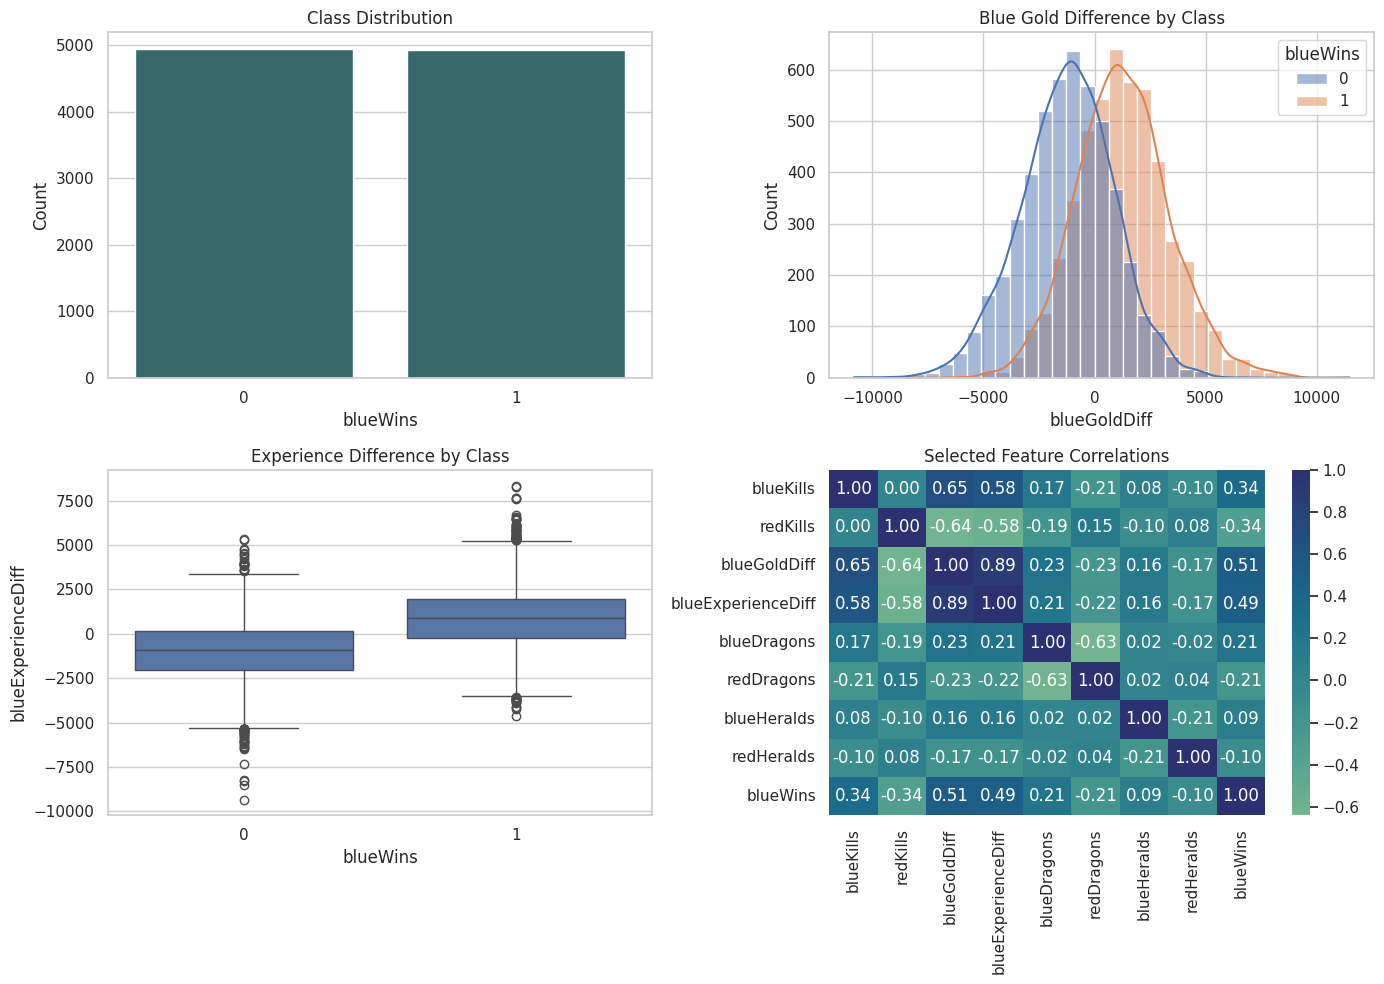

In [3]:
eda_columns = SELECTED_FEATURES + [TARGET_COLUMN]
display(data[eda_columns].describe().T)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mostra se as classes estão balanceadas ou desbalanceadas
sns.countplot(data=data, x=TARGET_COLUMN, ax=axes[0, 0], color="#2f6f73")
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_xlabel("blueWins")
axes[0, 0].set_ylabel("Count")

# Compara a distribuição da diferença de ouro entre partidas vencidas e perdidas pelo time azul
sns.histplot(data=data, x="blueGoldDiff", hue=TARGET_COLUMN, bins=35, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Blue Gold Difference by Class")
axes[0, 1].set_xlabel("blueGoldDiff")

# Usa boxplot para visualizar como a diferença de experiência varia por classe
sns.boxplot(data=data, x=TARGET_COLUMN, y="blueExperienceDiff", ax=axes[1, 0])
axes[1, 0].set_title("Experience Difference by Class")
axes[1, 0].set_xlabel("blueWins")
axes[1, 0].set_ylabel("blueExperienceDiff")

# Calcula correlações entre as features e o target
correlation_matrix = data[eda_columns].corr(numeric_only=True)
# Heatmap ajuda a enxergar relações lineares e redundância entre variáveis
sns.heatmap(correlation_matrix, cmap="crest", center=0, annot=True, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Selected Feature Correlations")

plt.tight_layout()
plt.show()

## 3. Pré-processamento e Separação Holdout

Esta seção valida o esquema esperado, remove a coluna identificadora da modelagem, trata valores ausentes (se existirem), codifica variáveis categóricas (se existirem) e separa atributos (`X`) do alvo (`y`). A separação holdout usa `stratify=y` e `random_state=42` para que treino e teste sejam reprodutíveis e mantenham o balanceamento das classes.

In [4]:
def prepare_features(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, dict[str, Any]]:
    # Garante que todas as colunas esperadas existem
    required_columns = [TARGET_COLUMN, *DROP_COLUMNS, *SELECTED_FEATURES]
    missing_columns = [column for column in required_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    # Remove linhas sem alvo, pois elas não podem ser usadas em aprendizado supervisionado
    model_data = data.dropna(subset=[TARGET_COLUMN]).copy()
    # Separa as features selecionadas em X e o target em y
    X = model_data[SELECTED_FEATURES].copy()
    y = model_data[TARGET_COLUMN].copy()

    # Identifica colunas numéricas e categóricas para aplicar tratamentos adequados
    numeric_columns = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()

    # Preenche valores ausentes numéricos com a mediana da respectiva coluna
    for column in numeric_columns:
        if X[column].isna().any():
            fill_value = X[column].median()
            X[column] = X[column].fillna(0 if pd.isna(fill_value) else fill_value)

    # Preenche valores ausentes categóricos com a moda; se não houver moda, usa 'missing'
    for column in categorical_columns:
        if X[column].isna().any():
            mode_values = X[column].mode(dropna=True)
            fill_value = mode_values.iloc[0] if not mode_values.empty else "missing"
            X[column] = X[column].fillna(fill_value)

    # Converte variáveis categóricas em variáveis dummy, caso existam no conjunto selecionado
    if categorical_columns:
        X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

    # Registra um resumo do que foi feito no pré-processamento
    preprocessing_report = {
        "dropped_columns": DROP_COLUMNS,
        "selected_features": SELECTED_FEATURES,
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "remaining_missing_values": int(X.isna().sum().sum()),
    }
    return X, y, preprocessing_report


# Executa a preparação de features e target
X, y, preprocessing_report = prepare_features(data)
# Mostra o relatório de pré-processamento para confirmar as decisões aplicadas
display(pd.DataFrame([preprocessing_report]))
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Divide os dados em treino e teste com holdout 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
# Verifica se a estratificação preservou proporções semelhantes de classes em treino e teste
display(
    pd.DataFrame(
        {
            "train_percent": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
            "test_percent": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
        }
    )
)

,dropped_columns,selected_features,numeric_columns,categorical_columns,remaining_missing_values
0,[gameId],"[blueKills, redKills, blueGoldDiff, blueExperi...","[blueKills, redKills, blueGoldDiff, blueExperi...",[],0


X shape: (9879, 8)
y shape: (9879,)
Training set: 7903 rows
Test set: 1976 rows


,train_percent,test_percent
blueWins,,
0,50.09,50.1
1,49.91,49.9


## 4. Pipelines e GridSearchCV

Esta seção define uma `Pipeline` e um espaço de busca `GridSearchCV` para cada um dos classificadores: KNN, Árvore de Decisão, Gaussian Naive Bayes e SVM. Cada pipeline possui `StandardScaler` como primeira etapa e o classificador como segunda etapa.

In [5]:
def build_model_specs() -> dict[str, tuple[Pipeline, list[dict[str, list[Any]]]]]:
    """Retorna um pipeline com scaler + classificador e uma grade compacta por algoritmo"""
    # Cada entrada do dicionário contém: nome do modelo, pipeline e combinações de hiperparâmetros
    return {
        "KNN": (
            # Pipeline do KNN: padroniza as features e depois aplica o classificador baseado em vizinhos
            Pipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    ("classifier", KNeighborsClassifier()),
                ]
            ),
            # Grade com 5 combinações variando número de vizinhos, ponderação e métrica de distância
            [
                {"classifier__n_neighbors": [3], "classifier__weights": ["uniform"], "classifier__p": [2]},
                {"classifier__n_neighbors": [5], "classifier__weights": ["uniform"], "classifier__p": [2]},
                {"classifier__n_neighbors": [7], "classifier__weights": ["distance"], "classifier__p": [2]},
                {"classifier__n_neighbors": [9], "classifier__weights": ["uniform"], "classifier__p": [1]},
                {"classifier__n_neighbors": [11], "classifier__weights": ["distance"], "classifier__p": [1]},
            ],
        ),
        "Decision Tree": (
            # Pipeline da Árvore de Decisão: inclui scaler para cumprir o requisito do trabalho
            Pipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
                ]
            ),
            # Grade com 5 combinações variando critério, profundidade e mínimo de amostras por folha
            [
                {"classifier__criterion": ["gini"], "classifier__max_depth": [3], "classifier__min_samples_leaf": [1]},
                {"classifier__criterion": ["gini"], "classifier__max_depth": [5], "classifier__min_samples_leaf": [5]},
                {"classifier__criterion": ["entropy"], "classifier__max_depth": [5], "classifier__min_samples_leaf": [5]},
                {"classifier__criterion": ["gini"], "classifier__max_depth": [7], "classifier__min_samples_leaf": [10]},
                {"classifier__criterion": ["entropy"], "classifier__max_depth": [9], "classifier__min_samples_leaf": [10]},
            ],
        ),
        "Gaussian Naive Bayes": (
            # Pipeline do Naive Bayes Gaussiano: padroniza e depois aplica o classificador probabilístico
            Pipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    ("classifier", GaussianNB()),
                ]
            ),
            # Grade com 5 valores de suavização para estabilidade numérica das variâncias
            [
                {"classifier__var_smoothing": [1e-9]},
                {"classifier__var_smoothing": [1e-8]},
                {"classifier__var_smoothing": [1e-7]},
                {"classifier__var_smoothing": [1e-6]},
                {"classifier__var_smoothing": [1e-5]},
            ],
        ),
        "SVM": (
            # Pipeline do SVM: padronização é especialmente importante para modelos baseados em margem
            Pipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    ("classifier", SVC(random_state=RANDOM_STATE)),
                ]
            ),
            # Grade com 5 combinações variando C e kernel linear/RBF
            [
                {"classifier__C": [0.1], "classifier__kernel": ["linear"], "classifier__gamma": ["scale"]},
                {"classifier__C": [1.0], "classifier__kernel": ["linear"], "classifier__gamma": ["scale"]},
                {"classifier__C": [10.0], "classifier__kernel": ["linear"], "classifier__gamma": ["scale"]},
                {"classifier__C": [1.0], "classifier__kernel": ["rbf"], "classifier__gamma": ["scale"]},
                {"classifier__C": [10.0], "classifier__kernel": ["rbf"], "classifier__gamma": ["scale"]},
            ],
        ),
    }

model_specs = build_model_specs()
for model_name, (pipeline, param_grid) in model_specs.items():
    print(f"{model_name}: pipeline steps = {[step_name for step_name, _ in pipeline.steps]}, grid combinations = {len(param_grid)}")

KNN: pipeline steps = ['scaler', 'classifier'], grid combinations = 5
Decision Tree: pipeline steps = ['scaler', 'classifier'], grid combinations = 5
Gaussian Naive Bayes: pipeline steps = ['scaler', 'classifier'], grid combinations = 5
SVM: pipeline steps = ['scaler', 'classifier'], grid combinations = 5


In [6]:
def calculate_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    """Calcula as métricas de classificação exigidas no conjunto de teste"""
    return {
        "test_accuracy": float(accuracy_score(y_true, y_pred)),
        "test_precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "test_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "test_f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def run_grid_searches(
    model_specs: dict[str, tuple[Pipeline, list[dict[str, list[Any]]]]],
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> tuple[pd.DataFrame, dict[str, GridSearchCV], dict[str, np.ndarray]]:
    """Executa GridSearchCV com 5 folds para cada modelo e avalia no conjunto holdout"""
    rows: list[dict[str, Any]] = []
    grid_searches: dict[str, GridSearchCV] = {}
    confusion_matrices: dict[str, np.ndarray] = {}

    for model_name, (pipeline, param_grid) in model_specs.items():
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=SCORING_METRIC,
            cv=CV_FOLDS,
            n_jobs=-1,
            refit=True,
        )
        grid_search.fit(X_train, y_train)
        predictions = grid_search.predict(X_test)
        metric_values = calculate_metrics(y_test, predictions)

        rows.append(
            {
                "model": model_name,
                "cv_best_f1": float(grid_search.best_score_),
                **metric_values,
                "best_params": grid_search.best_params_,
            }
        )
        grid_searches[model_name] = grid_search
        confusion_matrices[model_name] = confusion_matrix(y_test, predictions)

    comparison_df = pd.DataFrame(rows).sort_values(
        by=["test_f1", "test_accuracy"], ascending=False
    )
    return comparison_df, grid_searches, confusion_matrices


comparison_df, grid_searches, confusion_matrices = run_grid_searches(
    model_specs=model_specs,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

display(comparison_df)

,model,cv_best_f1,test_accuracy,test_precision,test_recall,test_f1,best_params
3,SVM,0.734677,0.717611,0.713147,0.726166,0.719598,"{'classifier__C': 0.1, 'classifier__gamma': 's..."
2,Gaussian Naive Bayes,0.725410,0.710526,0.708669,0.712982,0.710819,{'classifier__var_smoothing': 1e-09}
1,Decision Tree,0.721912,0.719636,0.733766,0.687627,0.709948,"{'classifier__criterion': 'gini', 'classifier_..."
0,KNN,0.702114,0.689271,0.691753,0.680527,0.686094,"{'classifier__n_neighbors': 11, 'classifier__p..."


## 5. Comparação de Modelos

Esta seção compara a melhor configuração validada por cross-validation de cada algoritmo usando métricas no conjunto holdout de teste. O modelo vencedor é selecionado pelo maior F1-score em teste, usando acurácia como critério secundário de desempate. Matrizes de confusão são plotadas para os quatro algoritmos para permitir inspeção dos padrões de erro, e não apenas do vencedor.

Winning model: SVM
Best hyperparameters:
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}


,model,cv_best_f1,test_accuracy,test_precision,test_recall,test_f1,best_params
3,SVM,0.734677,0.717611,0.713147,0.726166,0.719598,"{'classifier__C': 0.1, 'classifier__gamma': 's..."
2,Gaussian Naive Bayes,0.725410,0.710526,0.708669,0.712982,0.710819,{'classifier__var_smoothing': 1e-09}
1,Decision Tree,0.721912,0.719636,0.733766,0.687627,0.709948,"{'classifier__criterion': 'gini', 'classifier_..."
0,KNN,0.702114,0.689271,0.691753,0.680527,0.686094,"{'classifier__n_neighbors': 11, 'classifier__p..."


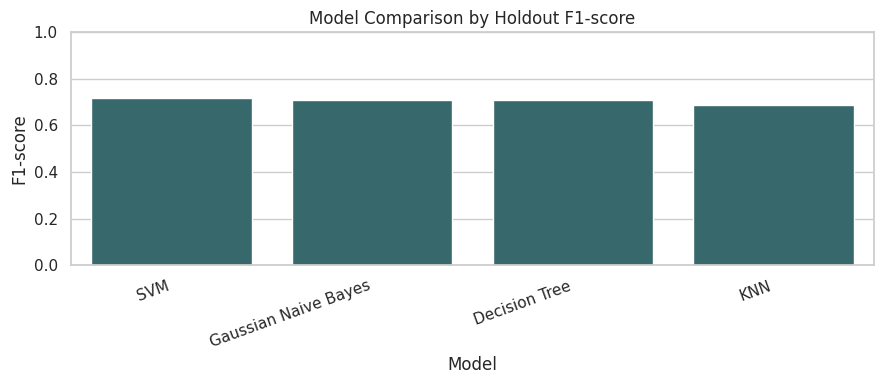

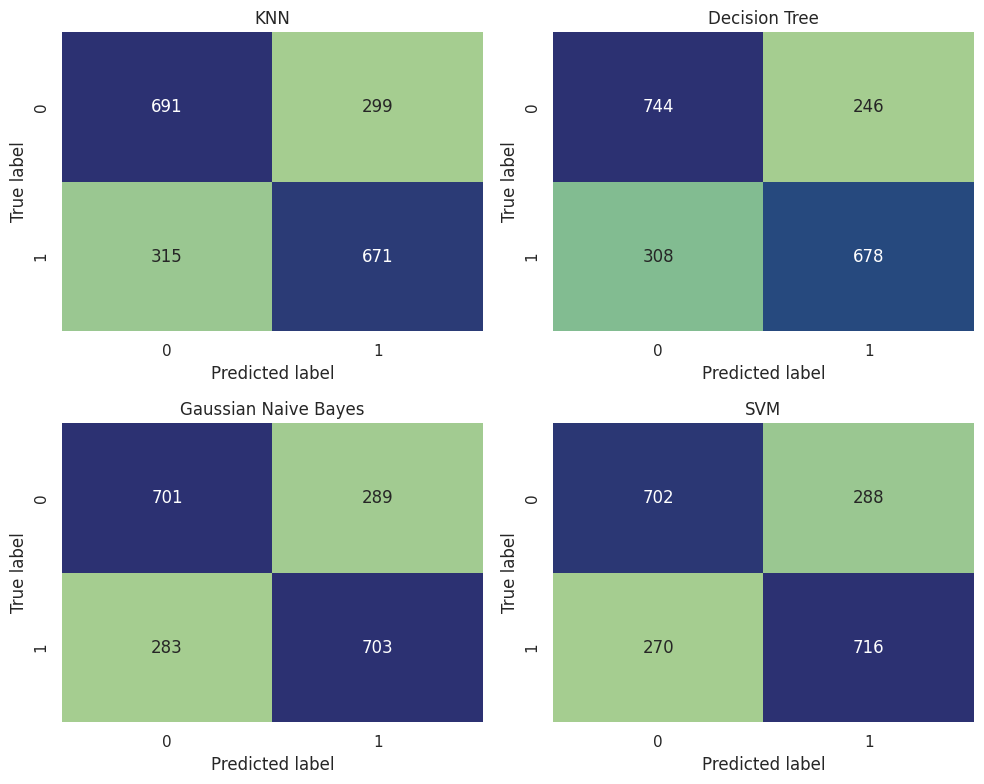

In [7]:
# Seleciona o modelo vencedor: primeira linha após ordenar por F1 e acurácia
winning_model_name = str(comparison_df.iloc[0]["model"])
winning_search = grid_searches[winning_model_name]

print(f"Winning model: {winning_model_name}")
print("Best hyperparameters:")
print(winning_search.best_params_)

# Reexibe a tabela comparativa com as métricas exigidas e a melhor configuração de cada algoritmo
display(
    comparison_df[
        ["model", "cv_best_f1", "test_accuracy", "test_precision", "test_recall", "test_f1", "best_params"]
    ]
)

# Gráfico de barras para comparar visualmente o F1-score de teste entre algoritmos
plt.figure(figsize=(9, 4))
sns.barplot(data=comparison_df, x="model", y="test_f1", color="#2f6f73")
plt.title("Model Comparison by Holdout F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Plota uma matriz de confusão para cada algoritmo, facilitando análise de erros por classe
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    # Cada heatmap mostra acertos e erros do melhor estimador daquela família
    sns.heatmap(matrix, annot=True, fmt="d", cmap="crest", cbar=False, ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

## 6. Treinamento Final do Modelo

`GridSearchCV(refit=True)` já ajusta a melhor configuração usando todo o conjunto de treino. Esta seção torna a etapa de reentreinamento explícita ao clonar a melhor pipeline vencedora, ajustá-la novamente com todos os dados de treino e avaliá-la mais uma vez no conjunto de teste ainda não utilizado.

Final retrained model: SVM
Final model hyperparameters:
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}


,test_accuracy,test_precision,test_recall,test_f1
SVM,0.717611,0.713147,0.726166,0.719598


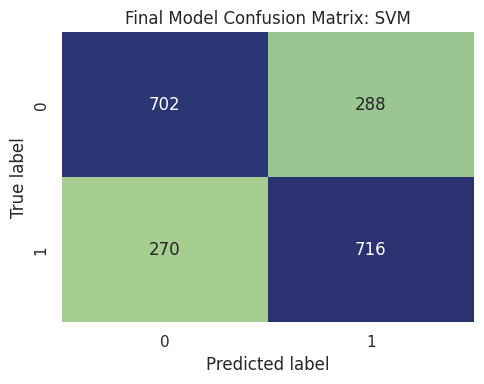

In [8]:
# Clona o melhor pipeline encontrado
final_model: BaseEstimator = clone(winning_search.best_estimator_)
# Ajusta novamente o pipeline vencedor usando todo o conjunto de treino
final_model.fit(X_train, y_train)

# Prediz o conjunto de teste uma última vez com o modelo final retreinado
final_predictions = final_model.predict(X_test)
final_metrics = calculate_metrics(y_test, final_predictions)
final_confusion_matrix = confusion_matrix(y_test, final_predictions)

print(f"Final retrained model: {winning_model_name}")
print("Final model hyperparameters:")
print(winning_search.best_params_)
display(pd.DataFrame([final_metrics], index=[winning_model_name]))

plt.figure(figsize=(5, 4))
sns.heatmap(final_confusion_matrix, annot=True, fmt="d", cmap="crest", cbar=False)
plt.title(f"Final Model Confusion Matrix: {winning_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

## 7. Exportação

Esta seção salva a pipeline final ajustada, incluindo `StandardScaler` e o classificador, como `modelo.pkl`. Também preserva o padrão de artefatos já usado no projeto gravando `artifacts/lol_model.pkl`, `artifacts/selected_features.json` e `artifacts/metrics.json` para reutilização posterior.

In [9]:
def make_json_safe(value: Any) -> Any:
    """Converte valores escalares/estruturas de NumPy e pandas em valores compatíveis com JSON."""
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {key: make_json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [make_json_safe(item) for item in value]
    return value


def export_artifacts(
    model: BaseEstimator,
    comparison_df: pd.DataFrame,
    final_metrics: dict[str, float],
    final_confusion_matrix: np.ndarray,
) -> list[Path]:
    """Persiste a pipeline final e os metadados de apoio."""
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    metrics_payload = {
        "selected_features": SELECTED_FEATURES,
        "best_model": winning_model_name,
        "best_params": winning_search.best_params_,
        "final_test_metrics": final_metrics,
        "final_confusion_matrix": final_confusion_matrix.tolist(),
        "comparison": comparison_df.to_dict(orient="records"),
        "test_size": TEST_SIZE,
        "random_state": RANDOM_STATE,
        "cv_folds": CV_FOLDS,
        "scoring_metric": SCORING_METRIC,
    }

    exported_paths = [
        MODEL_EXPORT_PATH,
        ARTIFACTS_DIR / "lol_model.pkl",
        ARTIFACTS_DIR / "selected_features.json",
        ARTIFACTS_DIR / "metrics.json",
    ]

    joblib.dump(model, MODEL_EXPORT_PATH)
    joblib.dump(model, ARTIFACTS_DIR / "lol_model.pkl")
    (ARTIFACTS_DIR / "selected_features.json").write_text(
        json.dumps(SELECTED_FEATURES, indent=2), encoding="utf-8"
    )
    (ARTIFACTS_DIR / "metrics.json").write_text(
        json.dumps(make_json_safe(metrics_payload), indent=2), encoding="utf-8"
    )
    return exported_paths


exported_paths = export_artifacts(final_model, comparison_df, final_metrics, final_confusion_matrix)
for path in exported_paths:
    print(path.resolve())

/content/modelo.pkl
/content/artifacts/lol_model.pkl
/content/artifacts/selected_features.json
/content/artifacts/metrics.json


## Conclusões

O notebook implementa um fluxo completo de classificação binária: carregamento via URL, diagnósticos básicos, EDA, pré-processamento, separação holdout estratificada, quatro pipelines com escalonamento e classificadores, `GridSearchCV` com 5 folds, avaliação holdout, comparação de modelos, reentreinamento final e exportação da pipeline final como `modelo.pkl`.

Usando o dataset atual, os atributos escolhidos para o MVP e os grids compactos acima, o modelo vencedor esperado é a pipeline SVM com kernel linear.